In [1]:
import pandas as pd
import plotly.express as px
import os


DATA_FOLDER = "data"
VIS_FOLDER = "vis"
SETS = ['SetA']#, 'SetB', 'SetC', 'SetD']

In [ ]:
def load_and_clean(set_name):
    print(f"Feldolgozás: {set_name}...")
    e_path = os.path.join(DATA_FOLDER, f"SCLDDOS2024_{set_name}_events.csv")
    c_path = os.path.join(DATA_FOLDER, f"SCLDDoS2024_{set_name}_components.csv")
    
    if not os.path.exists(e_path) or not os.path.exists(c_path):
        return None
    
   
    e_df = pd.read_csv(e_path, usecols=['Attack ID', 'Start time', 'End time', 'Type', 'Attack code'])
    c_df = pd.read_csv(c_path, usecols=['Attack ID', 'Packet speed', 'Data speed', 'Avg packet len', 'Source IP count'])
    
    df = e_df.merge(c_df, on='Attack ID', how='left')
    df['Set'] = set_name
    
    
    df['Start time'] = pd.to_datetime(df['Start time'], errors='coerce')
    df['End time'] = pd.to_datetime(df['End time'], errors='coerce')
    df['Duration_sec'] = (df['End time'] - df['Start time']).dt.total_seconds()
    

    df['Type'] = df['Type'].astype('category')
    df['Attack code'] = df['Attack code'].astype('category')
    
    return df

In [33]:
import pandas as pd
import numpy as np

def prep_data(df):
    """
    Adatok előkészítése:
    - Attack ID megtartása
    - Időalapú jellemzők (Day_of_week, Time_of_day)
    - Új jellemző: Packets_per_IP
    - Szűrések (NaN, Duration > 0, Source IP > 0)
    - Skálázás NÉLKÜL
    """
    df_prep = df.copy()

    # 1. Időalapú jellemzők kiszámítása
    df_prep['Day_of_week'] = df_prep['Start time'].dt.dayofweek
    df_prep['Time_of_day'] = df_prep['Start time'].dt.hour // 6

    # 2. Szigorú szűrések a mérési hibák ellen [cite: 89-94]
    # A Source IP count > 0 szűrés itt kritikus az osztás miatt (zéróosztás elkerülése)
    critical_cols = ['Packet speed', 'Data speed', 'Avg packet len', 'Source IP count', 'Duration_sec']
    df_prep = df_prep.dropna(subset=critical_cols + ['Type', 'Attack ID'])
    df_prep = df_prep[(df_prep['Duration_sec'] > 0) & (df_prep['Source IP count'] > 0)]

    # 3. Új jellemző kiszámítása: Packet speed / Source IP count
    # Megmutatja az egy forrásra jutó átlagos csomagsebességet
    df_prep['Packets_per_IP'] = df_prep['Packet speed'] / df_prep['Source IP count']

    # 4. Csak a szükséges oszlopok megtartása
    features_to_keep = [
        'Attack ID', 
        'Packet speed', 
        'Data speed', 
        'Avg packet len', 
        'Source IP count', 
        'Packets_per_IP', # <--- Új mező
        'Duration_sec', 
        'Day_of_week', 
        'Time_of_day',
        'Type'
    ]
    df_final = df_prep[features_to_keep].copy()

    # 5. Célváltozó kódolása [cite: 96, 122]
    from sklearn.preprocessing import LabelEncoder
    le_type = LabelEncoder()
    df_final['Label'] = le_type.fit_transform(df_final['Type'].astype(str))

    X = df_final.drop(columns=['Type', 'Label'])
    y = df_final['Label']

    return X, y, le_type

In [16]:
all_dfs = []
for s in SETS:
    data = load_and_clean(s)
    all_dfs.append(data)
print(all_dfs[0].head(10))




Feldolgozás: SetA...
   Attack ID          Attack code          Start time            End time  \
0          1  High volume traffic 2022-08-08 18:09:36 2022-08-08 18:09:37   
1          2  High volume traffic 2022-08-08 18:37:28 2022-08-08 18:37:28   
2          3  High volume traffic 2022-08-08 18:41:25 2022-08-08 18:41:26   
3          3  High volume traffic 2022-08-08 18:41:25 2022-08-08 18:41:26   
4          4  High volume traffic 2022-08-08 18:47:49 2022-08-08 18:47:50   
5          5  High volume traffic 2022-08-08 18:57:15 2022-08-08 18:58:11   
6          5  High volume traffic 2022-08-08 18:57:15 2022-08-08 18:58:11   
7          6   Suspicious traffic 2022-08-08 19:09:29 2022-08-08 19:09:29   
8          7  High volume traffic 2022-08-08 19:11:36 2022-08-08 19:11:37   
9          7  High volume traffic 2022-08-08 19:11:36 2022-08-08 19:11:37   

                 Type  Packet speed  Data speed  Avg packet len  \
0      Normal traffic       55600.0        73.0          1383.0 

In [34]:
prep_dfs = []
for df in all_dfs:
    X, y, le = prep_data(df)
    prep_dfs.append((X, y, le))

prep_dfs[0][0]
    

,Attack ID,Packet speed,Data speed,Avg packet len,Source IP count,Packets_per_IP,Duration_sec,Day_of_week,Time_of_day
0,1,55600.0,73.0,1383.0,6.0,9266.666667,1.0,0,3
2,3,59700.0,79.0,1399.0,1.0,59700.000000,1.0,0,3
3,3,65700.0,86.0,1399.0,1.0,65700.000000,1.0,0,3
4,4,59500.0,85.0,1486.0,1.0,59500.000000,1.0,0,3
5,5,74800.0,108.0,1518.0,1.0,74800.000000,56.0,0,3
...,...,...,...,...,...,...,...,...,...
586631,134763,53500.0,74.0,1462.0,2.0,26750.000000,3.0,3,2
586635,134765,73100.0,85.0,1185.0,2.0,36550.000000,82.0,3,2
586636,134765,60000.0,67.0,1257.0,5.0,12000.000000,82.0,3,2
586637,134766,52200.0,74.0,1506.0,1.0,52200.000000,3.0,3,2


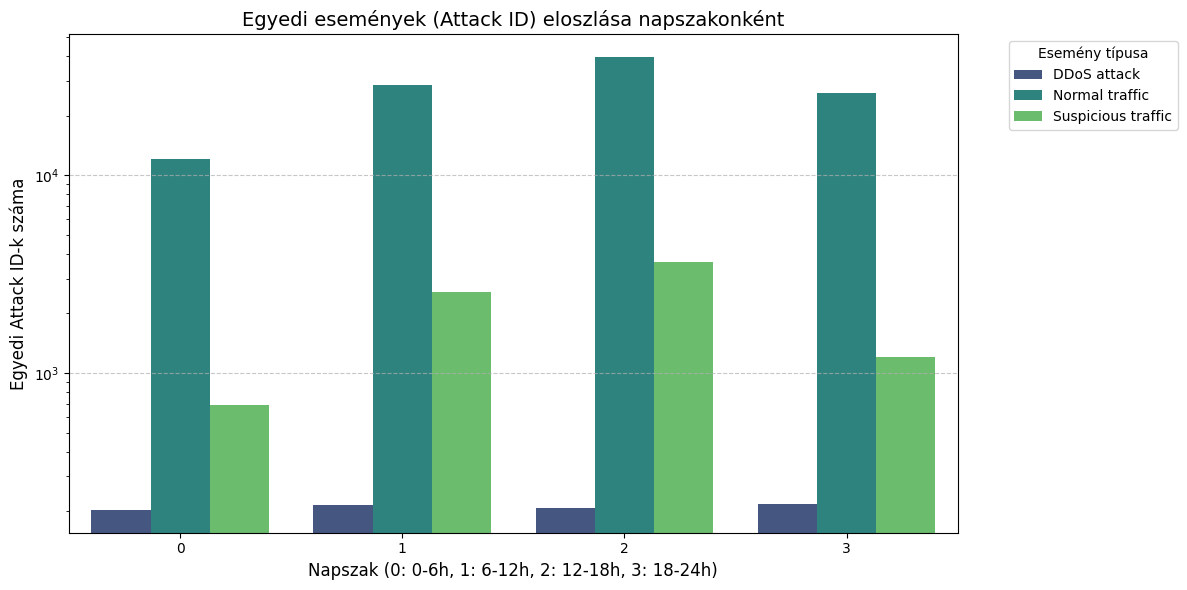

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_daily_distribution(X, y, le_type):
    """
    Bar chart készítése a napszakok (Time_of_day) és az egyedi Attack ID-k alapján.
    A színek (legend) az esemény típusát (Label) jelölik.
    """
    # 1. Adatok előkészítése a rajzoláshoz
    # X-ben benne van az 'Attack ID' és a 'Time_of_day', y-ban pedig a 'Label'
    plot_df = X.copy()
    plot_df['Label_ID'] = y
    
    # Visszaalakítjuk a numerikus Label-t olvasható szöveggé (pl. 0 -> 'Normal traffic')
    plot_df['Event Type'] = le_type.inverse_transform(y)

    # 2. Csoportosítás és az egyedi Attack ID-k megszámlálása
    # Napszakonként és típusonként számoljuk az UNIKÁLIS Attack ID-kat
    chart_data = plot_df.groupby(['Time_of_day', 'Event Type'])['Attack ID'].nunique().reset_index()
    chart_data.rename(columns={'Attack ID': 'Unique Attack Count'}, inplace=True)

    # 3. Bar chart kirajzolása
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=chart_data, 
        x='Time_of_day', 
        y='Unique Attack Count', 
        hue='Event Type',
        palette='viridis' # Szép kontrasztos színek
    )

    plt.yscale('log')

    # Dekoráció és magyarázatok
    plt.title('Egyedi események (Attack ID) eloszlása napszakonként', fontsize=14)
    plt.xlabel('Napszak (0: 0-6h, 1: 6-12h, 2: 12-18h, 3: 18-24h)', fontsize=12)
    plt.ylabel('Egyedi Attack ID-k száma', fontsize=12)
    plt.legend(title='Esemény típusa', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('attack_id_distribution.png')
    plt.show()

# Használat:
plot_daily_distribution(prep_dfs[0][0], prep_dfs[0][1], prep_dfs[0][2])

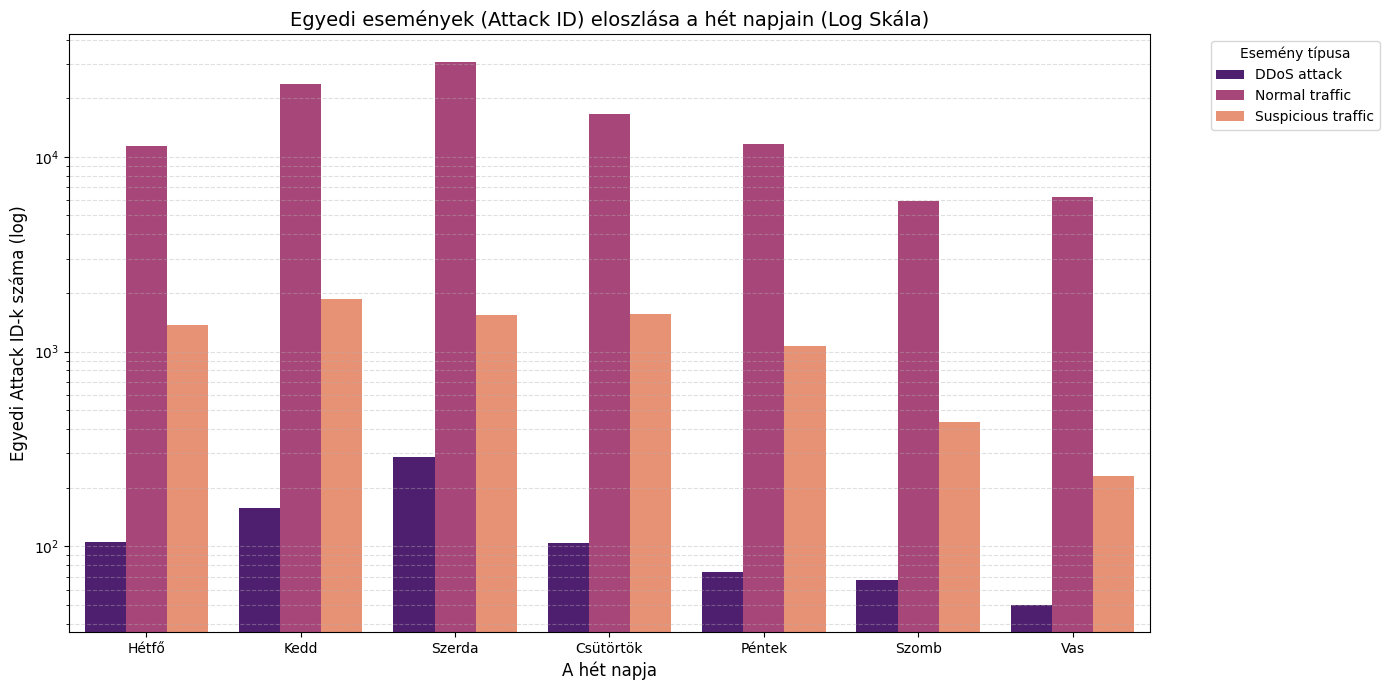

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weekly_distribution_log(X, y, le_type):
    """
    Bar chart készítése az egyedi Attack ID-k alapján a hét napjaira lebontva, 
    logaritmikus y-tengellyel.
    """
    # 1. Adatok összekészítése
    plot_df = X.copy()
    plot_df['Event Type'] = le_type.inverse_transform(y)
    
    # Napok nevei a jobb olvashatóságért
    days = {0: 'Hétfő', 1: 'Kedd', 2: 'Szerda', 3: 'Csütörtök', 4: 'Péntek', 5: 'Szomb', 6: 'Vas'}
    plot_df['Day_Name'] = plot_df['Day_of_week'].map(days)

    # 2. Egyedi Attack ID-k megszámlálása naponként és típusonként
    chart_data = plot_df.groupby(['Day_of_week', 'Day_Name', 'Event Type'])['Attack ID'].nunique().reset_index()
    chart_data.rename(columns={'Attack ID': 'Unique Attack Count'}, inplace=True)

    # 3. Rajzolás
    plt.figure(figsize=(14, 7))
    ax = sns.barplot(
        data=chart_data, 
        x='Day_Name', 
        y='Unique Attack Count', 
        hue='Event Type',
        palette='magma', # Más színpaletta a napszakos grafikontól való megkülönböztetéshez
        order=['Hétfő', 'Kedd', 'Szerda', 'Csütörtök', 'Péntek', 'Szomb', 'Vas']
    )

    # 4. Logaritmikus skála
    plt.yscale('log') 

    # Dekoráció
    plt.title('Egyedi események (Attack ID) eloszlása a hét napjain (Log Skála)', fontsize=14)
    plt.xlabel('A hét napja', fontsize=12)
    plt.ylabel('Egyedi Attack ID-k száma (log)', fontsize=12)
    plt.legend(title='Esemény típusa', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4, which="both")
    
    plt.tight_layout()
    plt.savefig('weekly_attack_distribution_log.png')
    plt.show()

# Használat:
plot_weekly_distribution_log(prep_dfs[0][0], prep_dfs[0][1], prep_dfs[0][2])